In [18]:

# Imports
import numpy as np

from snake.core.phantom import Phantom
from snake.core.sampling import EPI3dAcquisitionSampler
from snake.core.simulation import GreConfig, SimConfig, default_hardware
from snake.toolkit.plotting import axis3dcut



In [19]:
sim_conf = SimConfig(
    max_sim_time=6,
    seq=GreConfig(TR=50, TE=30, FA=3),
    hardware=default_hardware,
)
sim_conf.hardware.n_coils = 128
sim_conf.fov.res_mm = (3, 3, 3)

phantom = Phantom.from_brainweb(
    sub_id=4, sim_conf=sim_conf, output_res=1, tissue_file="tissue_7T"
)

# Here are the tissue availables and their parameters
contrast = phantom.contrast(sim_conf=sim_conf)
contrast.shape

No matrix size found in the header. The header is probably missing.


(60, 72, 60)

In [23]:
# Reconstructing a Single Frame of fully sampled EPI boils down to performing a 3D IFFT:

from scipy.fft import fftshift, ifftn, ifftshift, fftn

axes = (-3, -2, -1)
kspace_data = fftshift(fftn(ifftshift(contrast, axes=axes), axes=axes, norm="ortho"), axes=axes)

sigma = 0.01/np.sqrt(44)
noisy_kspace = kspace_data + (
    np.random.normal(0, sigma, kspace_data.shape) 
    + 1j * np.random.normal(0, sigma, kspace_data.shape)
)
image_data = ifftshift(
    ifftn(fftshift(noisy_kspace, axes=axes), axes=axes, norm="ortho"), axes=axes
)

# Take the square root sum of squares to get the magnitude image (SSOS)
# image_data = np.sqrt(np.sum(np.abs(image_data) ** 2, axis=0))


In [4]:
image_data.shape

(60, 72, 60)

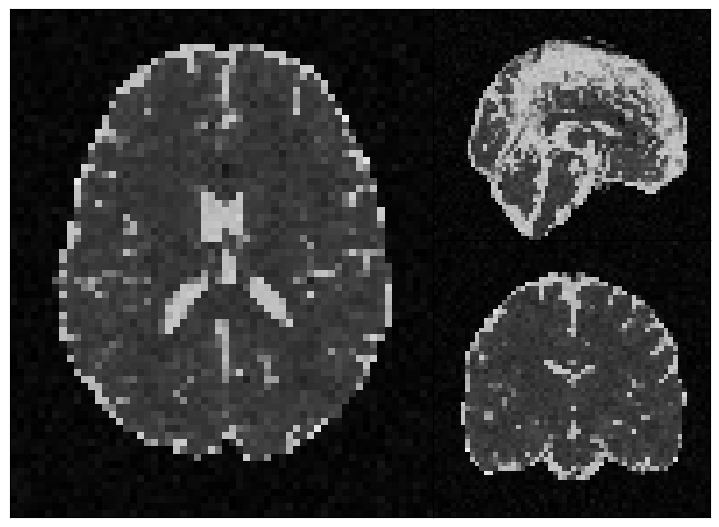

In [24]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots()

axis3dcut(np.abs(image_data).squeeze().T, None, None, cbar=False, cuts=(0.5, 0.5, 0.5), ax=ax)
plt.show()

In [20]:
from snake.core import get_smaps

smaps = get_smaps(contrast.shape, n_coils=44)
smaps.shape
smaps = np.ones(smaps.shape, dtype=np.complex64)
smaps = smaps / np.linalg.norm(smaps, axis=0, keepdims=True)

In [7]:
smaps[...,20].max()

np.complex64(1+0j)

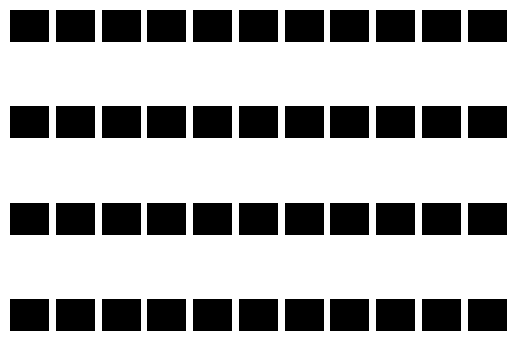

In [8]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4,11)

axes = axes.flatten()
for i in range(44):
    axes[i].imshow((np.abs(smaps))[i, :, :, 20], cmap='gray')
    axes[i].set_axis_off()



In [9]:
img_smaps =contrast[None,...] * smaps
img_smaps.shape

(44, 60, 72, 60)

In [10]:
from scipy.fft import fftshift, ifftn, ifftshift, fftn

axes = (-3, -2, -1)
kspace_data_smaps = fftshift(fftn(ifftshift(img_smaps, axes=axes), axes=axes, norm="ortho"), axes=axes)
kspace_data_smaps.shape

(44, 60, 72, 60)

In [21]:

sigma = 0.01/np.sqrt(44)
noise = np.random.normal(0, sigma, kspace_data_smaps.shape) + 1j*np.random.normal(0, sigma, kspace_data_smaps.shape)
noisy_kspace_smaps = kspace_data_smaps + noise
image_data_smaps = ifftshift(
    ifftn(fftshift(noisy_kspace_smaps, axes=axes), axes=axes, norm="ortho"), axes=axes
)

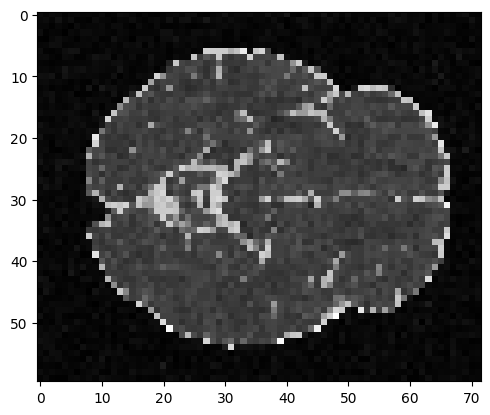

In [22]:
plt.imshow(np.abs(image_data_smaps)[12][:,:,20], cmap='gray')

In [25]:
coil_sum = np.sum(image_data_smaps * smaps.conj(),axis=0)
ssos = np.sqrt(np.sum(np.abs(image_data_smaps) ** 2, axis=0))


Text(0.5, 1.0, 'Single coil')

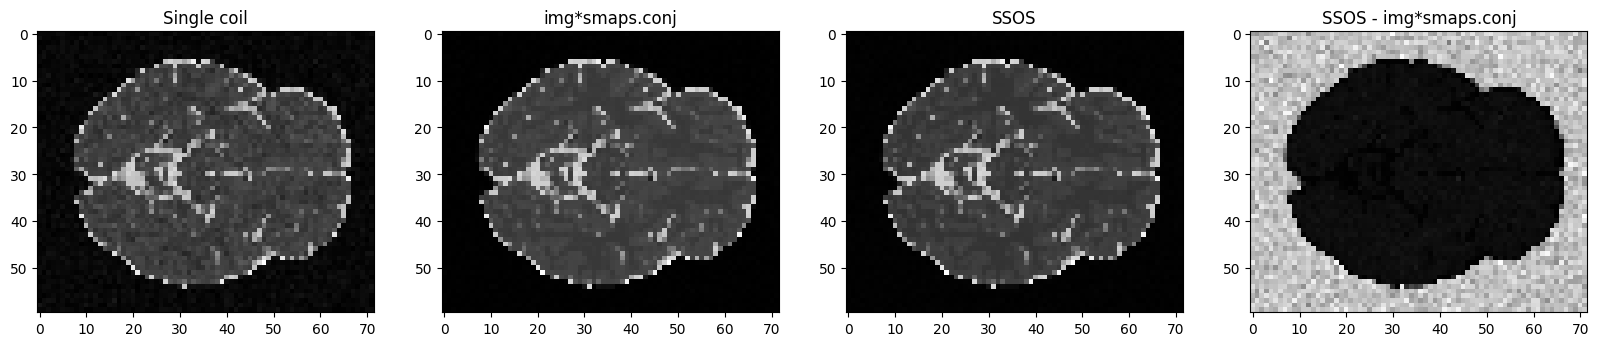

In [26]:
fig, axs = plt.subplots(1,4, figsize=(20,10))
axs[1].imshow(np.abs(coil_sum)[:,:,20], cmap='gray')
axs[1].set_title("img*smaps.conj")
axs[2].imshow(np.abs(ssos)[:,:,20], cmap='gray')
axs[2].set_title("SSOS")
axs[3].imshow((np.abs(ssos)-np.abs(coil_sum))[:,:,20], cmap='gray')
axs[3].set_title("SSOS - img*smaps.conj")
axs[0].imshow((np.abs(image_data))[:,:,20], cmap='gray')
axs[0].set_title("Single coil")

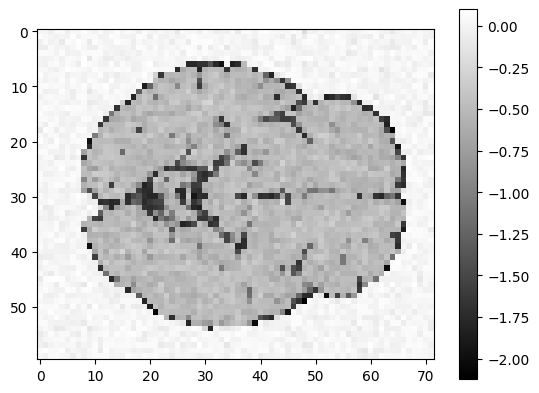

In [15]:
plt.imshow((np.abs(ssos)-np.abs(coil_sum))[:,:,20], cmap='gray')
plt.colorbar()

In [16]:
image_data_smaps = np.mean(image_data_smaps, axis=0)

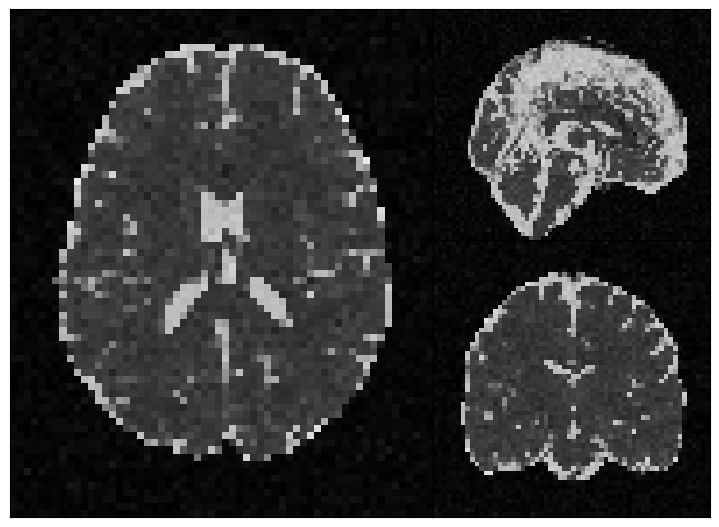

In [17]:
fig, ax = plt.subplots()

axis3dcut(np.abs(image_data_smaps).T, None, None, cbar=False, cuts=(0.5, 0.5, 0.5), ax=ax)
plt.show()
